# 02 — Crime by London borough

Goal: aggregate the cleaned London crime data by borough and crime type,
and produce our first real visualizations — a borough bar chart, a monthly
trend line, and a borough x crime-type heatmap.

In [1]:
import sys
sys.path.append("../../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from load_data import load_force_data
from clean import clean_crime_data, add_borough_column, LONDON_BOROUGHS

# sns.set_theme applies a consistent, readable default style (light grid,
# sensible fonts) to every matplotlib chart for the rest of the notebook,
# instead of setting it chart-by-chart.
sns.set_theme(style="whitegrid")

london = load_force_data("london")
london = clean_crime_data(london)
london = add_borough_column(london)
london.shape

(1235489, 9)

## Checking the borough extraction

`add_borough_column` parses "Borough" out of "LSOA name" by splitting off the
last space-separated token (the LSOA sub-code, e.g. "003C"). Before trusting
it, let's check what came out — because London should have exactly 33 areas
(32 boroughs + the City of London), and if we see more than that, something's
off.

In [2]:
london["Borough"].nunique()

325

### Finding: 325 "boroughs", not 33

Checked which rows have a Borough outside the real 33 London areas
(`LONDON_BOROUGHS` in `src/clean.py`): only **6,491 rows (0.53%)**, and over
half of those are "Violence and sexual offences". This matches a documented
data.police.uk practice — for sensitive offence categories, the published
location is sometimes deliberately anonymised to a point that can fall
outside the real force area, to protect victims. Since it's under 1% of
rows, we filter these out for borough-level analysis rather than let
mislabeled entries (e.g. "Manchester") clutter a London chart. The full
`london` DataFrame (all crime types, unfiltered) stays available for
anything that isn't borough-specific.

In [3]:
# .isin(...) checks membership in a set/list, row by row -> gives us a
# True/False mask the same length as the DataFrame, which we then use to
# filter with [].
ldn = london[london["Borough"].isin(LONDON_BOROUGHS)]
print(f"kept {len(ldn):,} of {len(london):,} rows ({len(ldn) / len(london):.2%})")

kept 1,228,998 of 1,235,489 rows (99.47%)


## Chart 1 — total crimes by borough

A horizontal bar chart: borough names are long, so bars running
left-to-right (via `barh`) keep every label readable without rotating text.
Bars are sorted by count so the ranking is immediately visible, and since
there's only one measure being shown (not multiple categories to tell
apart), every bar gets the same single color — color isn't doing any
identity work here, length is.

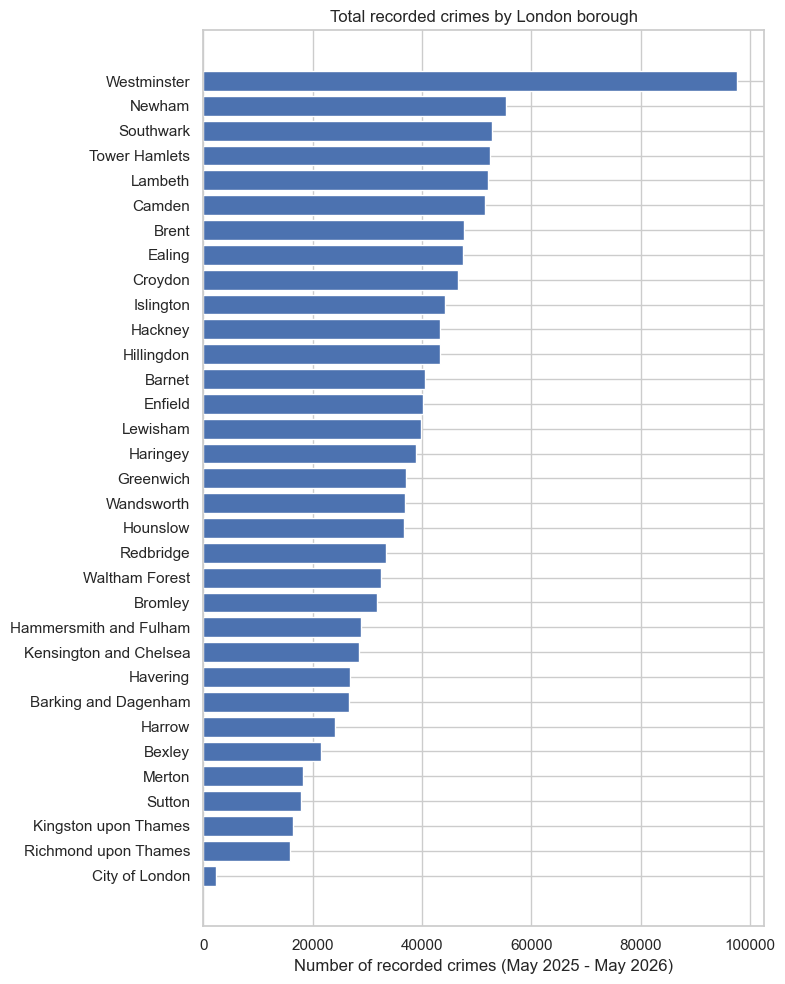

In [4]:
# groupby("Borough").size() counts rows per borough (like value_counts(),
# but works on the grouping column directly). sort_values(ascending=True)
# so that, combined with barh's bottom-to-top drawing order, the largest
# borough ends up at the TOP of the chart.
borough_counts = ldn.groupby("Borough").size().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(borough_counts.index, borough_counts.values, color="#4C72B0")
ax.set_xlabel("Number of recorded crimes (May 2025 - May 2026)")
ax.set_title("Total recorded crimes by London borough")
fig.tight_layout()

**Caveat, not a conclusion:** Westminster is far above every other borough —
but Westminster contains the West End, Oxford Street, and most of central
London's tourist/retail footfall, with a comparatively small resident
population. Raw counts conflate "lots of crime" with "lots of people passing
through." This is exactly why bringing in population data (a planned next
step) matters — it lets us compute a per-capita rate instead of just a
total.

## Chart 2 — monthly trend across Greater London

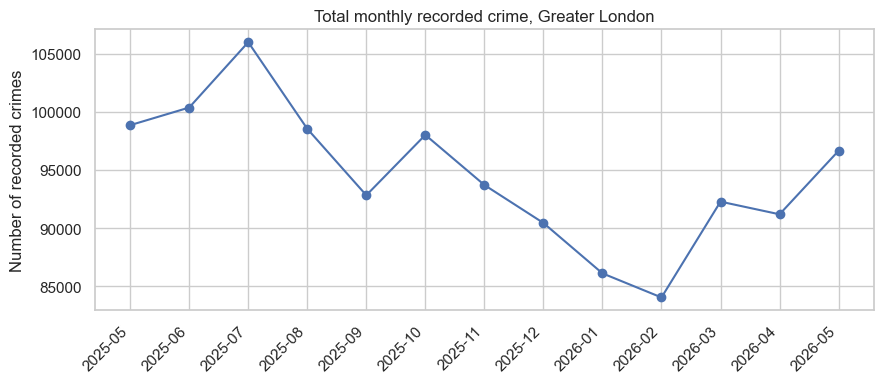

In [5]:
# Month strings sort correctly as plain text because "YYYY-MM" format sorts
# the same alphabetically as it does chronologically -> sort_index() is
# enough, no date parsing needed.
monthly_counts = ldn.groupby("Month").size().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly_counts.index, monthly_counts.values, marker="o", color="#4C72B0")
ax.set_ylabel("Number of recorded crimes")
ax.set_title("Total monthly recorded crime, Greater London")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()

## Chart 3 — crime type by borough (heatmap)

This is a magnitude comparison across two categories at once (borough x
crime type), so it uses a **sequential** color scale — one hue, light to
dark — rather than a rainbow of unrelated colors, which would wrongly imply
each cell is a distinct category instead of a point on the same numeric
scale.

All 14 crime types made the heatmap unreadable — most columns barely
registered any color, since a handful of categories (Bicycle theft,
Possession of weapons, Other crime, ...) are tiny compared to the top ones.
Trimming to the **top 6 crime types by total count** keeps every remaining
column visually meaningful. Worth being upfront about what that drops: the
excluded 8 categories still account for **~24% of all recorded crime** —
real, just spread thinly enough across many small categories that no single
one of them was pulling its own visual weight in a 14-column heatmap.</cell id="c9b7a0c3">


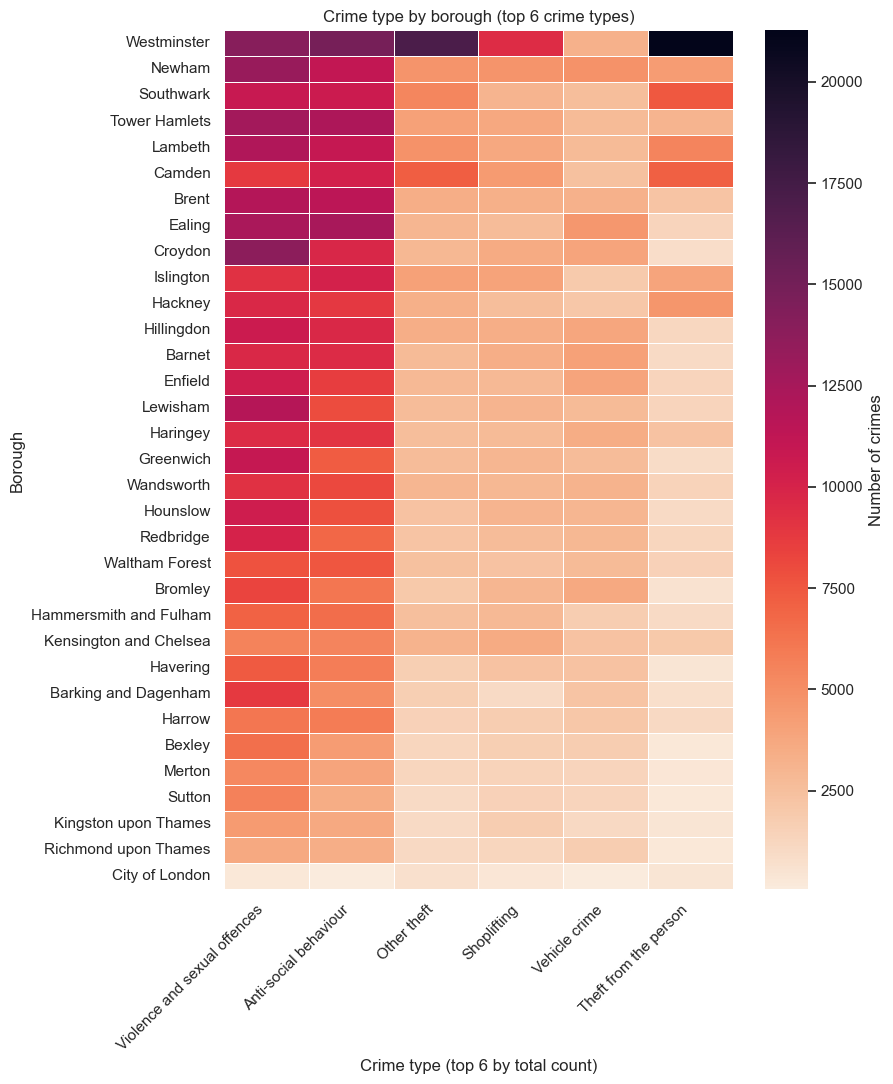

In [6]:
# pd.crosstab counts how many rows fall into each (Borough, Crime type)
# pair, laid out directly as a borough x crime-type grid -- exactly the
# shape a heatmap needs.
crime_type_order = ldn["Crime type"].value_counts().index

# Slicing the already-sorted index with [:6] keeps just the 6 most
# frequent crime types -- crime_type_order is sorted descending, so this
# is "top 6", not an arbitrary 6.
top_crime_types = crime_type_order[:6]

pivot = pd.crosstab(ldn["Borough"], ldn["Crime type"])

# Reorder rows by overall frequency (descending) so the busiest boroughs
# end up at the top, and select only the top 6 crime-type columns, in the
# same descending order.
pivot = pivot.loc[borough_counts.sort_values(ascending=False).index]
pivot = pivot[top_crime_types]

fig, ax = plt.subplots(figsize=(9, 11))
sns.heatmap(
    pivot,
    cmap="rocket_r",  # reversed "rocket": dark = high, light = low
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Number of crimes"},
    ax=ax,
)
ax.set_xlabel("Crime type (top 6 by total count)")
ax.set_ylabel("Borough")
ax.set_title("Crime type by borough (top 6 crime types)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()

### What to look for

Scan for boroughs whose row doesn't fit the general pattern of the columns
next to them (e.g. one crime type standing out much darker than the rest of
that row) — that's a borough with a distinctive crime profile, not just a
high overall total. Worth a closer look in a follow-up notebook once we add
population/deprivation data.